<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/PCA%20to%20reduce%20the%20dimensionality%20of%20a%20dataset%20using%20the%20Iris%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Data Shape: (150, 4) (150 samples, 4 features)
Reduced Data Shape: (150, 2) (150 samples, 2 principal components)

--- Explained Variance ---
PC1 explains: 72.96% of the variance
PC2 explains: 22.85% of the variance
Total variance retained: 95.81%


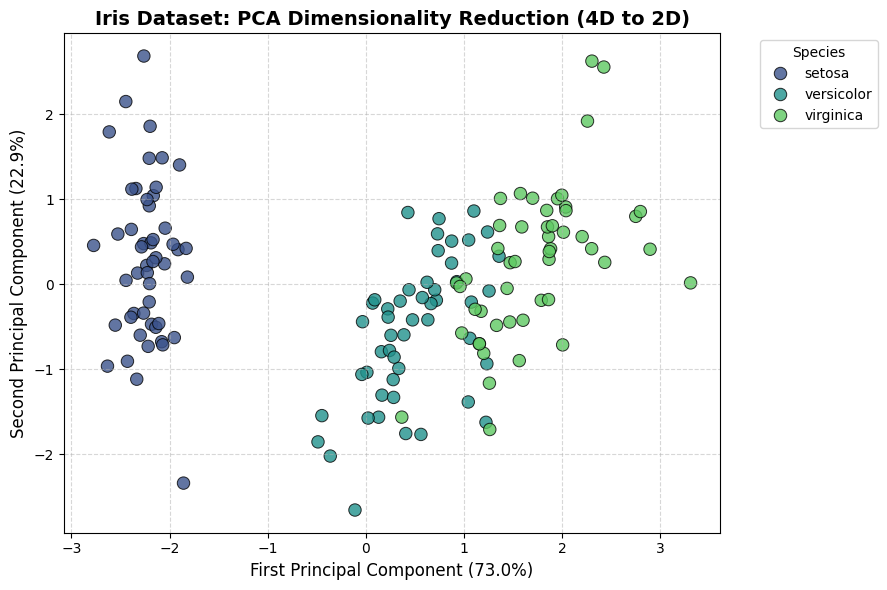


--- PCA Component Loadings (Feature Contributions) ---
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1              0.521            -0.269              0.580             0.565
PC2              0.377             0.923              0.024             0.067


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
iris = load_iris()
X = iris.data          # The 4 features
y = iris.target        # The target classes (0, 1, 2)
target_names = iris.target_names
feature_names = iris.feature_names

print(f"Original Data Shape: {X.shape} (150 samples, 4 features)")

# ==========================================
# 2. STANDARDIZE THE FEATURES (CRITICAL STEP)
# ==========================================
# PCA is highly sensitive to the scale of the data.
# If we don't scale, features with larger numerical ranges will dominate the variance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. APPLY PCA
# ==========================================
# We want to reduce the dimensionality from 4 to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Reduced Data Shape: {X_pca.shape} (150 samples, 2 principal components)")

# ==========================================
# 4. ANALYZE EXPLAINED VARIANCE
# ==========================================
explained_variance = pca.explained_variance_ratio_
print(f"\n--- Explained Variance ---")
print(f"PC1 explains: {explained_variance[0]*100:.2f}% of the variance")
print(f"PC2 explains: {explained_variance[1]*100:.2f}% of the variance")
print(f"Total variance retained: {sum(explained_variance)*100:.2f}%")

# ==========================================
# 5. CREATE A DATAFRAME FOR PLOTTING
# ==========================================
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = pd.Categorical.from_codes(y, target_names)

# ==========================================
# 6. VISUALIZE THE RESULTS
# ==========================================
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='species',
    palette='viridis',
    data=pca_df,
    s=80,
    edgecolor='k',
    alpha=0.8
)

plt.title('Iris Dataset: PCA Dimensionality Reduction (4D to 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'First Principal Component ({explained_variance[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Second Principal Component ({explained_variance[1]*100:.1f}%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 7. INSPECT FEATURE CONTRIBUTIONS (LOADINGS)
# ==========================================
# This tells us how much each original feature contributes to the Principal Components
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
).round(3)

print("\n--- PCA Component Loadings (Feature Contributions) ---")
print(loadings)